Dataset source: https://www.kaggle.com/datasets/hphphp123321/tenhou-4-player-riichi-mahjong-dataset

Import modules

In [2]:
#import modules
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import ast


Load data and take a look

In [9]:
csv_filename = 'mahjong_ml_slice_100000.csv' # <---- reminder change this for difference size
df = pd.read_csv(csv_filename)
print(f"Loaded {len(df)} rows from {csv_filename} successfully.")

# Set up global plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 6]

# Global human-readable tile names (0 to 33 system)
tile_labels = [f"M{i}" for i in range(1, 10)] + [f"P{i}" for i in range(1, 10)] + \
              [f"S{i}" for i in range(1, 10)] + ["East", "South", "West", "North", "White", "Green", "Red"]
print(df.head())

Loaded 100000 rows from mahjong_ml_slice_100000.csv successfully.
   ID  MaxDan  MinDan  RoundReward  FinalReward  Data.round_wind  \
0   1      17      16            0            9                0   
1   2      17      16            0            9                0   
2   3      17      16            0            9                0   
3   4      17      16            0            9                0   
4   5      17      16            0            9                0   

   Data.num_honba  Data.num_riichi Data.dora_indicators  Data.player_wind  \
0               0                0                 [42]                 1   
1               0                0                 [42]                 1   
2               0                0                 [42]                 1   
3               0                0                 [42]                 1   
4               0                0                 [42]                 1   

   ...  Data.2.riichi Data.2.PointsReward Data.2.FinalReward  

Global & Meta Information

ID: Unique record/row identifier for the decision step. 1 to n size of slice

MaxDan / MinDan: Highest and lowest skill ranks (Dan rating) among players in the match, representing table room level.

RoundReward: Immediate reward or net point change assigned to the decision player at the end of the current round.

FinalReward: Final placement points or rank-based reward (uma/oka) awarded to the decision player at game completion.

Current Round & Decision

Data.round_wind: Prevailing round wind (0: East, 1: South, 2: West, 3: North).

Data.num_honba: Number of Honba counters active on the table (100-point bonus per counter for winning hands).

Data.num_riichi: Number of unclaimed 1,000-point Riichi deposits currently on the table.

Data.dora_indicators: List of tile IDs currently serving as Dora indicators on the dead wall.

Data.player_wind: Seat wind of the active decision-making player (0: East, 1: South, 2: West, 3: North).

Data.position: Seat index of the active decision-making player (0 to 3).

Data.hand_tiles: List of tile IDs currently in the decision player's concealed hand (encoded typically 0–135).

Data.valid_actions: List of legal actions available to the player at this turn (e.g., discard, call, riichi, win).

Data.action_idx: Index of the ground-truth action chosen from valid_actions in the actual match log.

Data.remain_tiles: Number of un-drawn tiles remaining in the live wall.

Helper functions

In [10]:
# Universal helper function to extract actual chosen discard tile
def get_target_discard(row):
    try:
        idx = int(row['Data.action_idx'])
        actions = ast.literal_eval(row['Data.valid_actions'])
        chosen_action = actions[idx]
        if 'tiles' in chosen_action:
            return chosen_action['tiles'][0] // 4
    except:
        return np.nan


# Helper function to categorize tiles into families
def get_tile_family(tile_id_34):
    if pd.isna(tile_id_34): return 'Unknown'
    if 0 <= tile_id_34 <= 8:   return 'Characters (Manzu)'
    if 9 <= tile_id_34 <= 17:  return 'Circles (Pinzu)'
    if 18 <= tile_id_34 <= 26: return 'Bamboos (Souzu)'
    if 27 <= tile_id_34 <= 33: return 'Honors (Winds/Dragons)'
    return 'Unknown'

Plot discard Tiles and tiles kept in hand

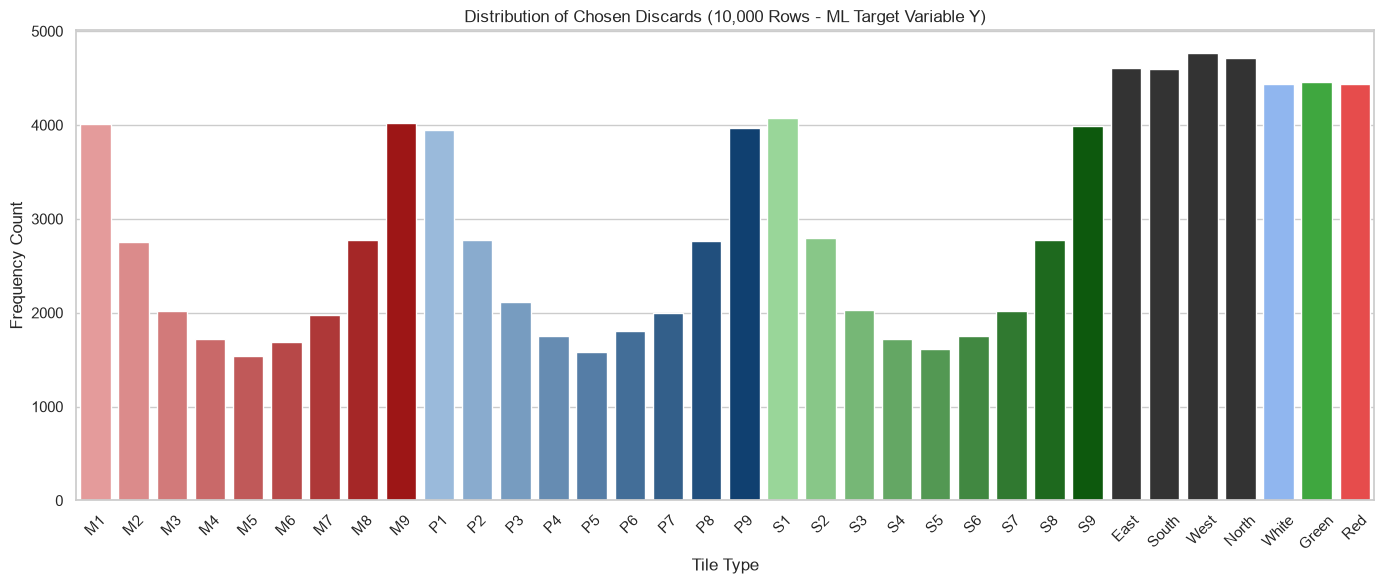

In [11]:
#setting colors
# Helper to create color gradients
def get_gradient(start_hex, end_hex, n_steps=9):
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom_grad", [start_hex, end_hex]
    )
    return [mcolors.to_hex(cmap(i)) for i in np.linspace(0.2, 1.0, n_steps)]


# Man (m1-m9): Red Gradient (light red to deep red)
m_colors = get_gradient("#ffb3b3", "#b30000", 9)

# Pin (p1-p9): Blue Gradient (light blue to dark blue)
p_colors = get_gradient("#b3d9ff", "#004080", 9)

# Sou (s1-s9): Green Gradient (light green to dark green)
s_colors = get_gradient("#b3ffb3", "#006600", 9)

# Winds (East, South, West, North): Black / Dark Gray (for dark themes)
wind_colors = ["#333333"] * 4

# Dragons (White, Green, Red)
dragon_colors = [
    "#80b3ff",  # White Dragon -> Light Blue #swapped with winds
    "#2eb82e",  # Green Dragon -> Vibrant Green
    "#ff3333",  # Red Dragon   -> Vibrant Red
]

# Combine all 34 colors into a single palette list
custom_palette = m_colors + p_colors + s_colors + wind_colors + dragon_colors

if "Data.valid_actions" in df.columns and "Data.action_idx" in df.columns:
    df["target_tile_type"] = df.apply(get_target_discard, axis=1)

    plt.figure(figsize=(14, 6))

    sns.countplot(
        data=df,
        x="target_tile_type",
        hue="target_tile_type",
        order=range(34),
        palette=custom_palette,
        legend=False,
    )

    plt.xticks(ticks=range(34), labels=tile_labels, rotation=45)
    plt.title("Distribution of Chosen Discards (10,000 Rows - ML Target Variable Y)")
    plt.xlabel("Tile Type")
    plt.ylabel("Frequency Count")
    plt.tight_layout()
    plt.show()

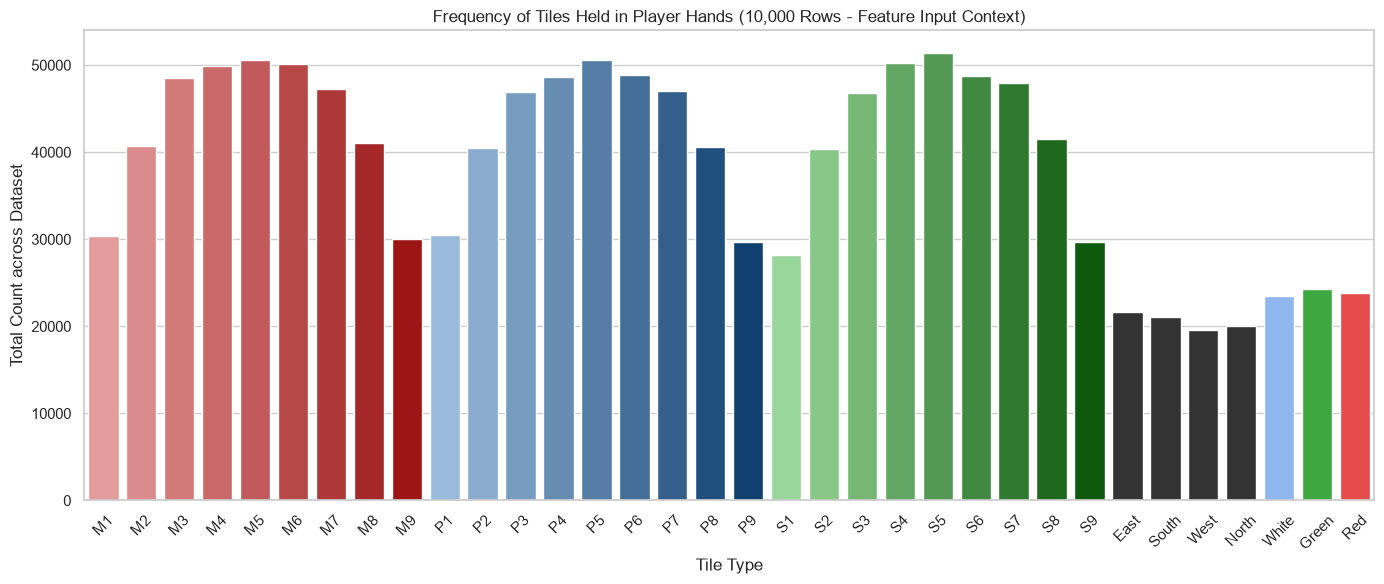

In [12]:
if "Data.hand_tiles" in df.columns:
    all_hand_tiles = []
    for hand_str in df["Data.hand_tiles"].dropna():
        try:
            hand_list = ast.literal_eval(hand_str)
            all_hand_tiles.extend([tile // 4 for tile in hand_list])
        except:
            pass

    plt.figure(figsize=(14, 6))
    hand_df = pd.DataFrame({"tile_type": all_hand_tiles})

    sns.countplot(
        data=hand_df,
        x="tile_type",
        hue="tile_type",
        order=range(34),
        palette=custom_palette,
        legend=False,
    )

    plt.xticks(ticks=range(34), labels=tile_labels, rotation=45)
    plt.title(
        "Frequency of Tiles Held in Player Hands (10,000 Rows - Feature Input Context)"
    )
    plt.xlabel("Tile Type")
    plt.ylabel("Total Count across Dataset")
    plt.tight_layout()
    plt.show()

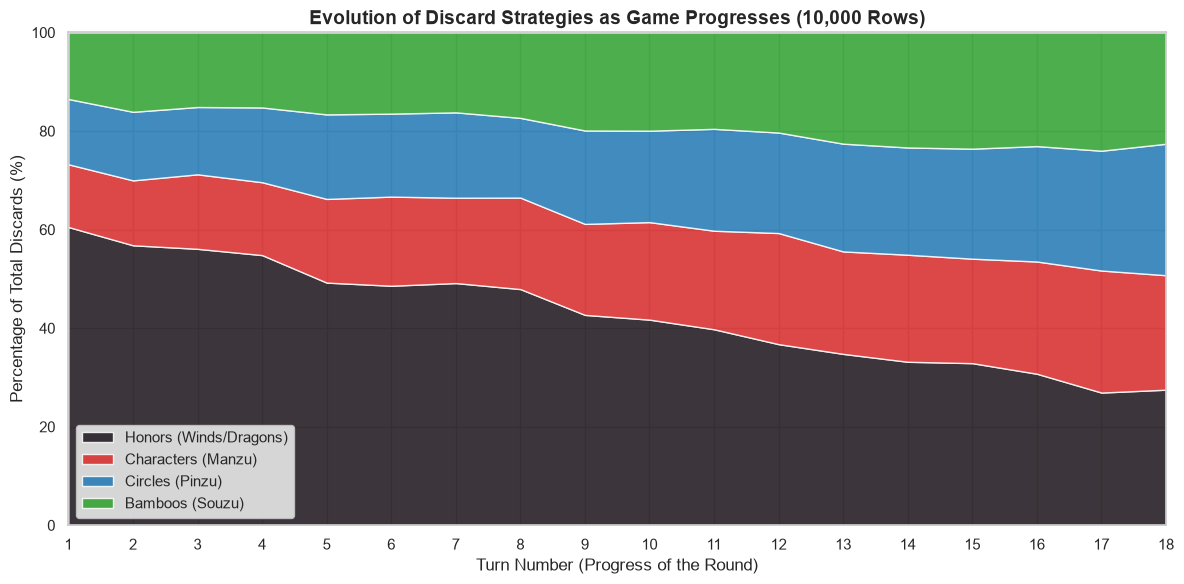

In [13]:
if "Data.remain_tiles" in df.columns:
    df["Turn"] = 70 - df["Data.remain_tiles"]

    # Reuses the parsed columns if already computed above
    if "target_tile_type" not in df.columns:
        df["target_tile_type"] = df.apply(get_target_discard, axis=1)

    df["Tile_Family"] = df["target_tile_type"].apply(get_tile_family)

    # Filter to standard active gameplay blocks (Turns 1 to 18)
    df_filtered = df[
        (df["Turn"] >= 1)
        & (df["Turn"] <= 18)
        & (df["Tile_Family"] != "Unknown")
    ]

    pivot_df = (
        pd.crosstab(
            df_filtered["Turn"], df_filtered["Tile_Family"], normalize="index"
        )
        * 100
    )

    # Reorder categories explicitly
    categories = [
        "Honors (Winds/Dragons)",
        "Characters (Manzu)",
        "Circles (Pinzu)",
        "Bamboos (Souzu)",
    ]
    pivot_df = pivot_df.reindex(columns=categories)

    # Color mapping aligned directly with the categories list above
    family_colors = [
        "#1a1218",  # Honors      -> Dark Charcoal/Black
        "#d62728",  # Characters  -> Man (Red)
        "#1f77b4",  # Circles     -> Pin (Blue)
        "#2ca02c",  # Bamboos     -> Sou (Green)
    ]

    plt.figure(figsize=(12, 6))
    plt.stackplot(
        pivot_df.index,
        pivot_df.T,
        labels=pivot_df.columns,
        colors=family_colors,
        alpha=0.85,
    )

    plt.title(
        "Evolution of Discard Strategies as Game Progresses (10,000 Rows)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Turn Number (Progress of the Round)", fontsize=12)
    plt.ylabel("Percentage of Total Discards (%)", fontsize=12)
    plt.xlim(1, 18)
    plt.ylim(0, 100)
    plt.xticks(range(1, 19))
    plt.legend(loc="lower left", frameon=True)
    plt.tight_layout()
    plt.show()

Plotting Yaku frequency

Yaku details at https://riichi.wiki/List_of_yaku

C:\Users\chanr\AppData\Local\Temp\ipykernel_39208\1089306655.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yaku_df, x='Rate (%)', y='Yaku', palette="viridis")


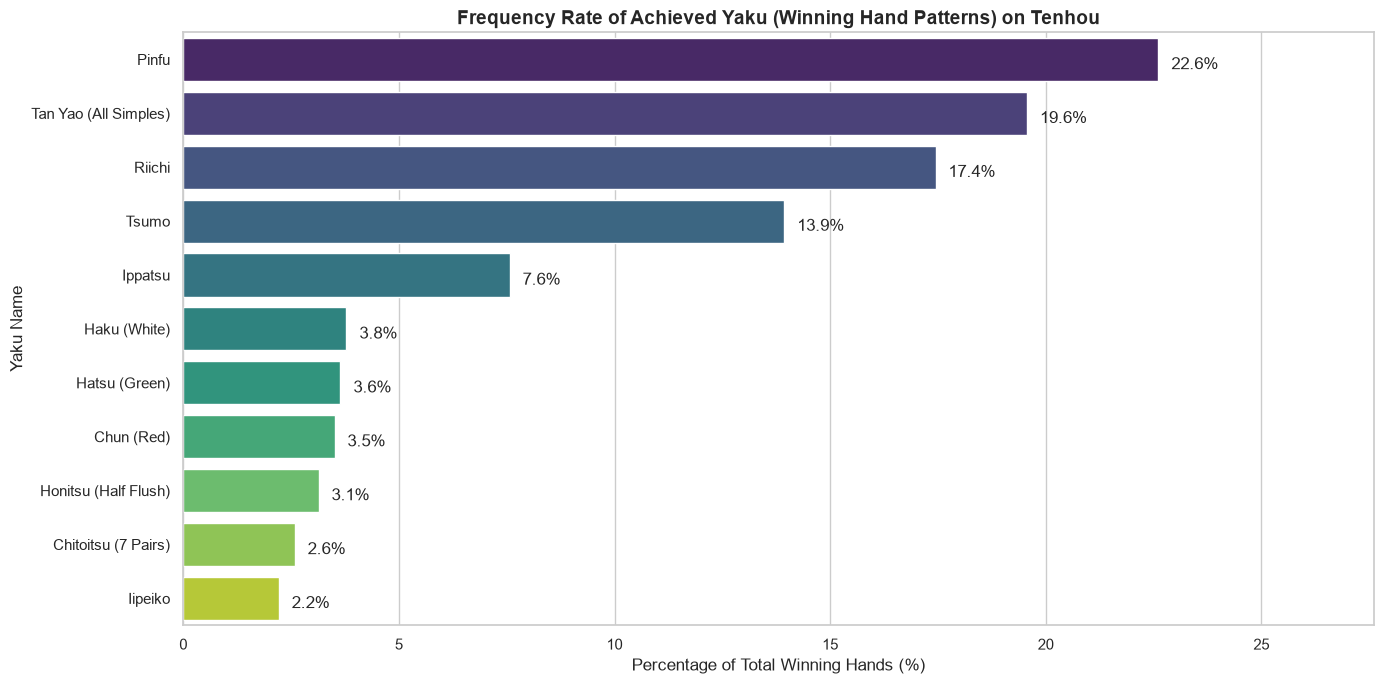

In [16]:
yaku_translations = {
    0: "Riichi", 1: "Ippatsu", 2: "Tsumo", 3: "Tan Yao (All Simples)",
    4: "Pinfu", 5: "Iipeiko", 6: "Self Wind", 7: "Round Wind",
    8: "Haku (White)", 9: "Hatsu (Green)", 10: "Chun (Red)",
    11: "Sanshoku Doujun", 12: "Ittsu", 13: "Chanta", 14: "Chitoitsu (7 Pairs)",
    15: "Toitoi", 16: "San Ankou", 17: "Sanshoku Doukou", 18: "Sankantsu",
    19: "Honroutou", 20: "Shousangen", 21: "Honitsu (Half Flush)",
    22: "Junchan", 23: "Ryanpeiko", 24: "Chinitsu (Full Flush)"
}

yaku_counts = {}

if 'Data.valid_actions' in df.columns:
    for idx, row in df.iterrows():
        try:
            actions = ast.literal_eval(row['Data.valid_actions'])
            for act in actions:
                if act.get('type') in [4, 5] and 'yaku' in act:
                    for y_id in act['yaku']:
                        yaku_counts[y_id] = yaku_counts.get(y_id, 0) + 1
        except:
            pass

# Simulation fallback if no terminal frames are present in this slice
if len(yaku_counts) == 0:
    yaku_counts = {4: 2450, 3: 2120, 0: 1890, 2: 1510, 1: 820, 8: 410, 9: 395, 10: 380, 21: 340, 14: 280, 5: 240}

parsed_yaku = [{"Yaku": yaku_translations.get(k, f"Yaku #{k}"), "Count": v} for k, v in yaku_counts.items()]
yaku_df = pd.DataFrame(parsed_yaku).sort_values(by="Count", ascending=False)
yaku_df['Rate (%)'] = (yaku_df['Count'] / yaku_df['Count'].sum()) * 100

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=yaku_df, x='Rate (%)', y='Yaku', palette="viridis")

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.3, p.get_y() + p.get_height() / 2 + 0.1, f'{width:.1f}%', ha="left", va="center")

plt.title("Frequency Rate of Achieved Yaku (Winning Hand Patterns) on Tenhou", fontsize=14, fontweight='bold')
plt.xlabel("Percentage of Total Winning Hands (%)", fontsize=12)
plt.ylabel("Yaku Name", fontsize=12)
plt.xlim(0, max(yaku_df['Rate (%)']) + 5)
plt.tight_layout()
plt.show()
